<a href="https://colab.research.google.com/github/shaima-zbeda/convex-optimization-course-project/blob/main/project_opt_25_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports and stting functions

In [ ]:
# @title Imports
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import time

In [ ]:
# @title Data Loader
print("Loading Data...")
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_data = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
x_train = train_data.data
image_size = x_train.shape[1] * x_train.shape[2]
x_train = x_train.reshape(-1, image_size).float() / 255

Loading Data...


In [ ]:
# @title AutoEncoder
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(image_size, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, image_size), nn.Sigmoid()
        )
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
#init autoencoder
autoencoder = Autoencoder()

## oracle functions
you should use to given model, loss function and x returns either the model output, the loss, the gradient and the hessian.

In [ ]:
def autoencoder_oracle(model, criterion, x, calc_hessian=False):
    """
    Computes f(x), gradient, and Hessian for a given input x.
    """
    # Forward Pass
    reconstructed_x = model(x)
    loss = criterion(reconstructed_x, x)

    grads = torch.autograd.grad(loss, model.parameters(), create_graph=calc_hessian)

    hessians = []

    if calc_hessian:
        for i, (grad, param) in enumerate(zip(grads, model.parameters())):

            grad_flat = grad.view(-1)

            hessian_rows = []
            for j in range(len(grad_flat)):

                grad_2nd = torch.autograd.grad(grad_flat[j], param, retain_graph=True)[0]
                hessian_rows.append(grad_2nd.view(-1))

            hessian_matrix = torch.stack(hessian_rows)
            hessians.append(hessian_matrix)


    return loss, grads, hessians

# The cell that define the Batch Size

In [ ]:
print("Initializing the model (Defining the function surface)...")
train_dataset = TensorDataset(x_train)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# This dataset is for the second order learners - so you wont run out of RAM
small_train_dataset = TensorDataset(x_train[:100]) # רק 100 תמונות להדגמה
small_train_loader = DataLoader(small_train_dataset, batch_size=10, shuffle=True)



Initializing the model (Defining the function surface)...


## Examples for optimizers

In [ ]:
def gd_step(x, grad_f_x, learning_rate=0.1):
    """
    Performs one step of Gradient Descent.
    Formula: x_new = x - lr * gradient
    """
    x_new = x - learning_rate * grad_f_x

    return x_new

In [ ]:
def newton_step(x, grad_f_x, hessian_f_x, learning_rate=1.0):
    """
    Performs one step of Newton-Raphson optimization on a batch.
    Shapes:
      x: (Batch, Dim)
      grad_f_x: (Batch, Dim)
      hessian_f_x: (Batch, Dim, Dim)
    """
    # 1. Calculate Inverse Hessian
    # torch.linalg.pinv handles batch dimensions automatically (Batch, D, D)
    hessian_inv = torch.linalg.pinv(hessian_f_x)

    # 2. Prepare Gradient for Batch Matrix Multiplication
    # grad_f_x is (Batch, D). We need (Batch, D, 1) for matmul
    grad_unsqueezed = grad_f_x.unsqueeze(2)

    # 3. Compute Update Direction: H^-1 * Gradient
    # (Batch, D, D) x (Batch, D, 1) -> (Batch, D, 1)
    update_direction = torch.matmul(hessian_inv, grad_unsqueezed)

    # 4. Remove extra dimension: (Batch, D, 1) -> (Batch, D)
    update_direction = update_direction.squeeze(2)

    # 5. Apply Update
    x_new = x - learning_rate * update_direction

    return x_new

# Experiment

In [ ]:
def run_model_optimization_experiment(
    optimizer_type: str,
    model: nn.Module,
    criterion: nn.Module,
    train_loader: DataLoader,
    epochs: int,
    learning_rate: float
):
    """
    Runs an optimization experiment to train the MODEL using GD or Newton.
    Closer to the requested structure.
    """
    all_losses = []
    print(f"\nStarting MODEL {optimizer_type.upper()} optimization for {epochs} epochs (lr={learning_rate})...")
    total_start_time = time.time()

    for epoch in range(epochs):
        epoch_loss = 0

        for batch_idx, batch in enumerate(train_loader):
            img = batch[0]

            calc_hessian_for_oracle = (optimizer_type == 'newton')
            loss, grads, hessians = autoencoder_oracle(model, criterion, img, calc_hessian=calc_hessian_for_oracle)

            epoch_loss += loss.item()

            # 2. Optimization step
            with torch.no_grad():
                if optimizer_type == 'gd':
                    for param, grad in zip(model.parameters(), grads):
                        param.data = gd_step(param.data, grad, learning_rate)

                elif optimizer_type == 'newton':
                    if hessians is None:
                        raise ValueError("Hessian missing for Newton method")
                    for param, grad, hessian in zip(model.parameters(), grads, hessians):
                        param.data = newton_step(param.data, grad, hessian, learning_rate)

                else:
                    raise ValueError("Invalid optimizer type")

        avg_loss = epoch_loss / len(train_loader)
        all_losses.append(avg_loss)


        if (epoch + 1) % (epochs // 5) == 0 or epoch == 0 or epoch == epochs - 1:
            print(f"  Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.6f}")

    total_end_time = time.time()
    total_training_time = total_end_time - total_start_time
    print(f"\nTotal Training Time: {total_training_time:.2f} seconds")
    print(f"Finished {optimizer_type.upper()} optimization. Final Loss: {all_losses[-1]:.6f}")
    return model, all_losses

In [ ]:
# epochs = 10
# lr = 0.1
# model = Autoencoder()
# criterion = nn.MSELoss()

# trained_model, losses = run_model_optimization_experiment(
#     'gd', model, criterion, train_loader, epochs, lr
# )

### Loss Curves Over Epochs

In [ ]:
# plt.figure(figsize=(10, 6))
# plt.plot(losses, label=f'GD (LR={lr})')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Optimization Loss Over Epochs')
# plt.legend()
# plt.grid(True)
# plt.show()

# The code for Adam Optimizer

In [ ]:
class Adam_Optimizer:

  def __init__(self, model_parameters, lr=0.001, beta1=0.95, beta2=0.999, epsilon=1e-6, weight_decay=0.01):
    """
    Initializes the Adam Optimizer.

    Args:
        model_parameters: list of model parameters (usually model.parameters())
        lr: Learning Rate (alpha)
        beta1: Decay rate for first moment (momentum)
        beta2: Decay rate for second moment (variance)
        epsilon: Small number to prevent division by zero
        weight_decay: L2 regularization strength --> in Adam its zero
    """
    self.params = list(model_parameters)
    self.lr = lr
    self.beta1 = beta1
    self.beta2 = beta2
    self.epsilon = epsilon
    self.weight_decay = weight_decay

    # Initilize memory (state) for every parameter
    # We need to store 'm' [momentum] 'v' [variance] for every weight matrix
    self.state = []

    for param in self.params:
      self.state.append({
          'm': torch.zeros_like(param.data), # First Momentum
          'v': torch.zeros_like(param.data), # Second Momentum/Variance
          't': 0                             # Time step

      })

  def step(self, grads):
    """
    Performs a single optimization step (updates weights).

    Args:
        grads: The list of gradients returned by autoencoder_oracle
    """
    # First: we need to iterate through the Parameters, Gradients and State simultaneously
    for param, grad, state in zip(self.params, grads, self.state):

      # If there is no gradients for this parameter just skip
      if grad is None:
        continue

      # this is related to the decay
      if self.weight_decay > 0:
        param.data = param.data - (self.lr * self.weight_decay * param.data)

      # 1. Update Time Step -> t
      state['t'] += 1
      t = state['t']


      # 2. Update Biased First Momentum Estimate [m]
      # The Formula given in the algorithm for the article:
      # m_t = beta1 * m_{t-1} + (1 - beta1) * g_t
      state['m'] =  self.beta1 * state['m'] + (1 - self.beta1) * grad


      # 3. Update Biased Second Raw Momentum/Variance Estimate [v]
      # The Formula given in the algorithm for the article:
      # v_t = beta2 * v_t{t-1} + (1 - beta2) * g_t^2
      state['v'] = self.beta2 * state['v'] + (1 - self.beta2) * (grad**2)


      # 4. Compute Bias-Corrected First Moment [m_hat]
      # The Formula given in the algorithm from the article
      # m_hat = m_t / (1 - beta1^t)
      m_hat = state['m'] / (1 - (self.beta1**t))


      # 5. Compute Bias-Corrected Second Raw Moment [v_hat]
      # The Formula given in the algorithm from the article:
      # v_hat = v_t / (1 - beta2^t)
      v_hat = state['v'] / (1 - (self.beta2**t))


      # 6. Update Parameters --> The ACTUAl "STEP"
      # The Formula given in the algorithm from the article:
      # theta_t = theta_{t-1} - alpha * m_hat / (sqrt(v_hat) + epsilon)

      # A. Do the complex calculation
      step_update = self.lr * m_hat / (torch.sqrt(v_hat) + self.epsilon)

      # B. calculate the final result
      param.data = param.data - step_update

# Experiment with Regular Adam

## The Run model code


In [ ]:
def run_model_optimization_experiment_with_adam(
    optimizer_type: str,
    model: nn.Module,
    criterion: nn.Module,
    train_loader: DataLoader,
    epochs: int,
    learning_rate: float
):
    """
    Runs an optimization experiment to train the MODEL using Adam.
    Closer to the requested structure.
    """
    all_losses = []
    print(f"\nStarting MODEL {optimizer_type.upper()} optimization for {epochs} epochs (lr={learning_rate})...")
    total_start_time = time.time()

    adam_optimizer = None
    if optimizer_type == 'adam':
       my_optimizer = Adam_Optimizer(model.parameters(), learning_rate)

    for epoch in range(epochs):
        epoch_loss = 0

        for batch_idx, batch in enumerate(train_loader):
            img = batch[0]

            calc_hessian_for_oracle = (optimizer_type == 'newton')
            loss, grads, hessians = autoencoder_oracle(model, criterion, img, calc_hessian=calc_hessian_for_oracle)

            epoch_loss += loss.item()

            # 2. Optimization step
            with torch.no_grad():
                if optimizer_type == 'adam':
                   my_optimizer.step(grads)

                else:
                    raise ValueError("Invalid optimizer type")

        avg_loss = epoch_loss / len(train_loader)
        all_losses.append(avg_loss)
        print(avg_loss)


        if (epoch + 1) % (epochs // 5) == 0 or epoch == 0 or epoch == epochs - 1:
            print(f"  Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.6f}")

    total_end_time = time.time()
    total_training_time = total_end_time - total_start_time
    print(f"\nTotal Training Time: {total_training_time:.2f} seconds")
    print(f"Finished {optimizer_type.upper()} optimization. Final Loss: {all_losses[-1]:.6f}")
    return model, all_losses

## The Experiment


Starting MODEL ADAM optimization for 38 epochs (lr=0.0045)...
0.03383703550486677
  Epoch [1/38] Loss: 0.033837
0.0203361050454157
0.017438083769940237
0.015953301787694125
0.015020962721153872
0.014319518130264684
0.013760429471413463
  Epoch [7/38] Loss: 0.013760
0.013284889665414402
0.012918723514800006
0.012640112153153176
0.012372722994210496
0.012092170968794747
0.011910205361431342
0.011757513534015556
  Epoch [14/38] Loss: 0.011758
0.011646661422908433
0.011501869661356212
0.011402356988394946
0.011277156210800351
0.011152833827268848
0.011045955500797804
0.011005563945420134
  Epoch [21/38] Loss: 0.011006
0.01092707816122183
0.010822586403456706
0.010809825773019272
0.010785326820367308
0.010690244798387673
0.010684344079544042
0.010599795508502262
  Epoch [28/38] Loss: 0.010600
0.010600456813060398
0.010530937262483116
0.010537333425078819
0.010447162094273802
0.010428571678412112
0.010406085248313733
0.010371621030924925
  Epoch [35/38] Loss: 0.010372
0.010322302144997792
0

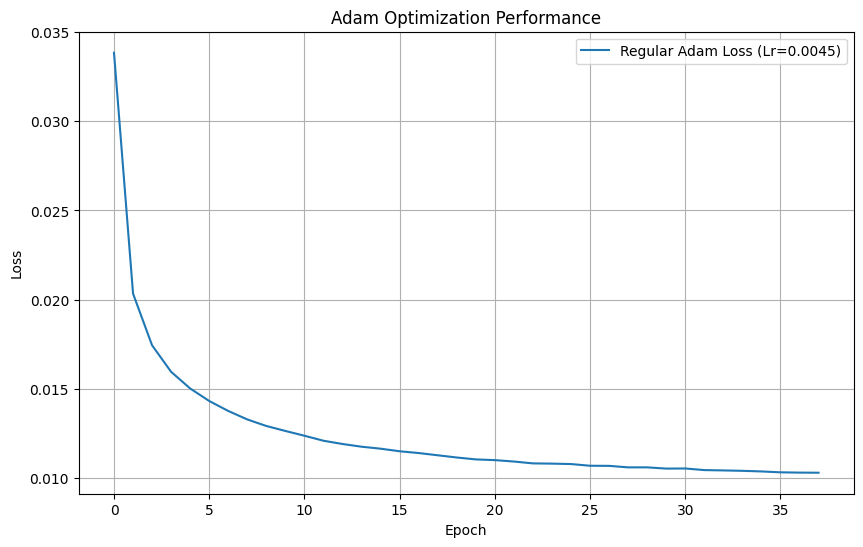

In [ ]:
# 1. Define your hyperparameters
optimizer_type = 'adam'
epochs = 38
learning_rate = 0.0045

# 2. Call the function
# We pass the 'autoencoder' model and 'train_loader' that were defined earlier in the notebook
trained_model, adam_losses = run_model_optimization_experiment_with_adam(
    optimizer_type,
    Autoencoder(),
    nn.MSELoss(),
    train_loader,
    epochs,
    learning_rate
)

# 3. Plot the results (Optional but recommended)
plt.figure(figsize=(10, 6))
plt.plot(adam_losses, label=f'Regular Adam Loss (Lr={learning_rate})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Adam Optimization Performance')
plt.legend()
plt.grid(True)
plt.show()

## The Reconstruction


Visualizing Results...


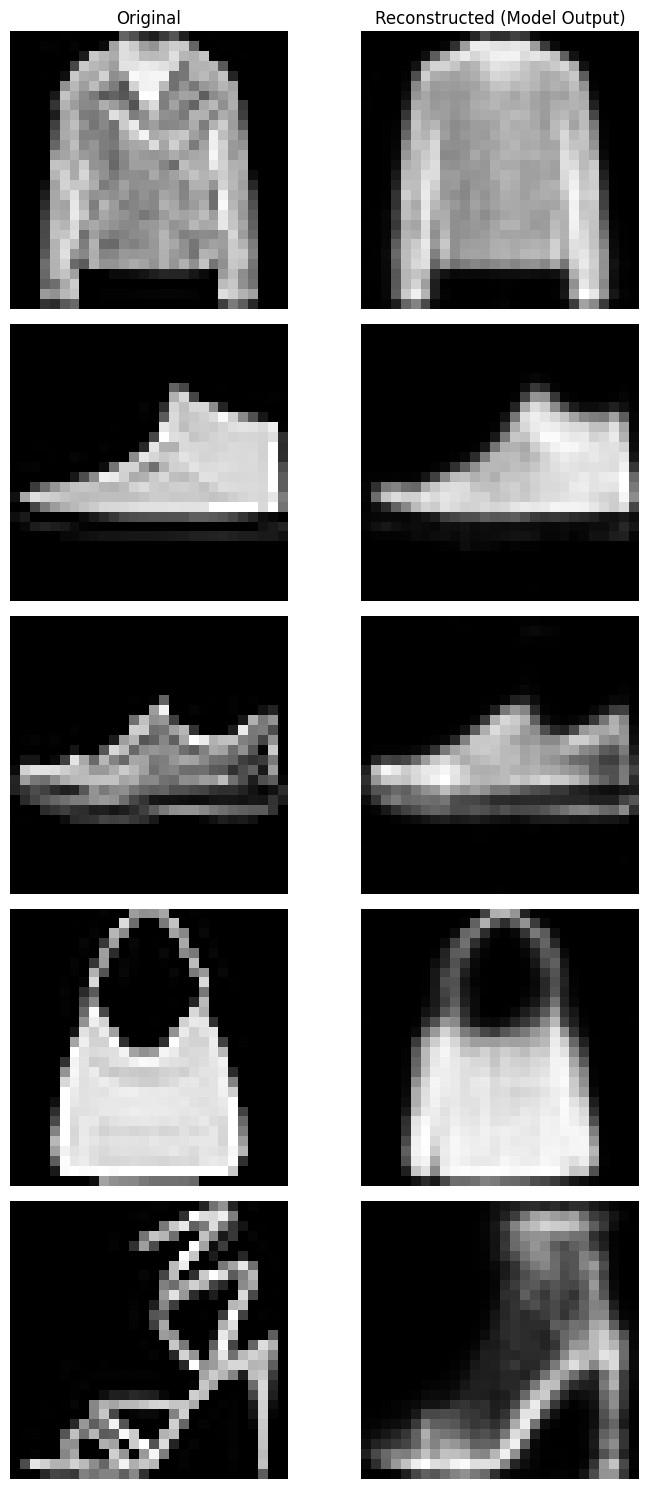

In [ ]:
def show_model_reconstructions_adam(model, batch_images, count=5):
    """
    Visualizes original images vs. model reconstructions.
    """
    print("\nVisualizing Results...")

    model.eval()

    with torch.no_grad():
        inputs = batch_images[:count]
        reconstructions = model(inputs)

    plt.figure(figsize=(8, 3 * count))

    for i in range(count):
        img_orig = inputs[i].cpu().numpy().reshape(28, 28)
        img_recon = reconstructions[i].cpu().numpy().reshape(28, 28)

        # Original
        ax = plt.subplot(count, 2, i*2 + 1)
        plt.imshow(img_orig, cmap='gray')
        if i == 0: ax.set_title("Original")
        plt.axis('off')

        #Reconstructed
        ax = plt.subplot(count, 2, i*2 + 2)
        plt.imshow(img_recon, cmap='gray')
        if i == 0: ax.set_title("Reconstructed (Model Output)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# ---use example ---
data_iter = iter(train_loader)
sample_images = next(data_iter)[0]

show_model_reconstructions_adam(trained_model, sample_images, count=5)

# The Experiment with Adam with warm up

## The Run model code


In [ ]:
import math
def run_model_optimization_experiment_with_adam_warm_up(
    optimizer_type: str,
    model: nn.Module,
    criterion: nn.Module,
    train_loader: DataLoader,
    epochs: int,
    learning_rate: float
):
    """
    Runs an optimization experiment to train the MODEL using Adam.
    Closer to the requested structure.
    """
    all_losses = []
    print(f"\nStarting MODEL {optimizer_type.upper()} optimization for {epochs} epochs (lr={learning_rate})...")
    total_start_time = time.time()

    max_lr = 0.0045
    min_lr = 0.0001
    warm_up_epochs = 5
    current_lr = 0.0

    adam_optimizer = None
    if optimizer_type == 'adam_with_warm_up':
       my_optimizer = Adam_Optimizer(model.parameters(), learning_rate)

    for epoch in range(epochs):
        if epoch < warm_up_epochs:
          current_lr = max_lr * ((epoch + 1) / warm_up_epochs)

        else:
          progress = (epoch - warm_up_epochs) / (epochs - warm_up_epochs)
          cosine_decay = 0.5 * (1 + math.cos(math.pi * progress))
          current_lr = min_lr + (max_lr - min_lr) * cosine_decay

        my_optimizer.lr = current_lr
        epoch_loss = 0


        for batch_idx, batch in enumerate(train_loader):
            img = batch[0]

            calc_hessian_for_oracle = (optimizer_type == 'newton')
            loss, grads, hessians = autoencoder_oracle(model, criterion, img, calc_hessian=calc_hessian_for_oracle)

            epoch_loss += loss.item()

            # 2. Optimization step
            with torch.no_grad():
                if optimizer_type == 'adam_with_warm_up':
                   my_optimizer.step(grads)

                else:
                    raise ValueError("Invalid optimizer type")

        avg_loss = epoch_loss / len(train_loader)
        all_losses.append(avg_loss)
        print(avg_loss)


        if (epoch + 1) % (epochs // 5) == 0 or epoch == 0 or epoch == epochs - 1:
            print(f"  Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.6f}")

    total_end_time = time.time()
    total_training_time = total_end_time - total_start_time
    print(f"\nTotal Training Time: {total_training_time:.2f} seconds")
    print(f"Finished {optimizer_type.upper()} optimization. Final Loss: {all_losses[-1]:.6f}")
    return model, all_losses

## The Experiment


Starting MODEL ADAM_WITH_WARM_UP optimization for 38 epochs (lr=0.0045)...
0.05162963051118576
  Epoch [1/38] Loss: 0.051630
0.02438000669833948
0.019710575720902953
0.01750676309876541
0.015944115902934628
0.014776799827814102
0.013922441822252295
  Epoch [7/38] Loss: 0.013922
0.013346106759203015
0.012859132361294491
0.012508256511806424
0.012165262751074742
0.011935272819992068
0.011627403508895623
0.011441980202648559
  Epoch [14/38] Loss: 0.011442
0.011241639308980915
0.011049192676793284
0.010868222653262143
0.010653050868575379
0.010530688732401776
0.010397005701131785
0.010270285811314958
  Epoch [21/38] Loss: 0.010270
0.010145410142743639
0.010011894104164292
0.009914230676427452
0.009808830763977854
0.009717645697486298
0.009632949230831061
0.009548641228949084
  Epoch [28/38] Loss: 0.009549
0.009480485663826723
0.009425426270367939
0.00935512617417077
0.009308896658977847
0.009262901390277183
0.009222056314563637
0.009185774635070804
  Epoch [35/38] Loss: 0.009186
0.0091605

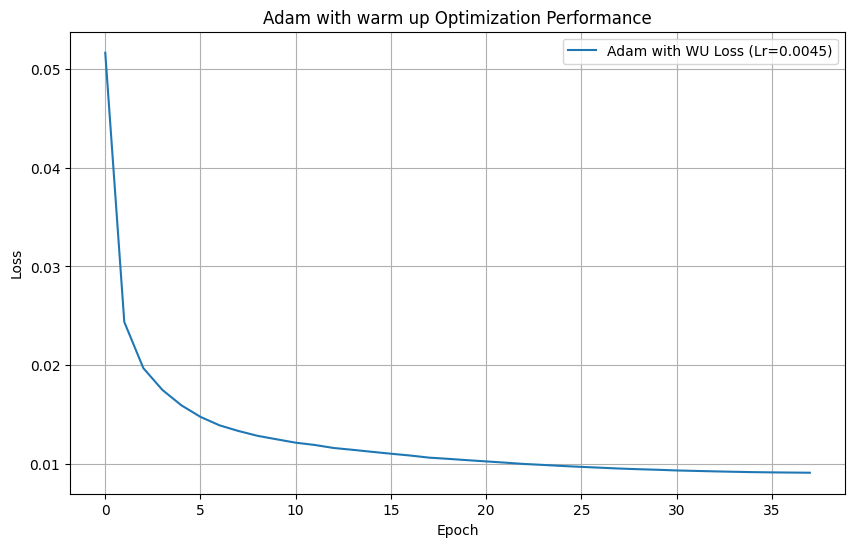

In [ ]:
# 1. Define your hyperparameters
optimizer_type = 'adam_with_warm_up'
epochs = 38
learning_rate = 0.0045

# 2. Call the function
# We pass the 'autoencoder' model and 'train_loader' that were defined earlier in the notebook
trained_model, adam_warm_up_losses = run_model_optimization_experiment_with_adam_warm_up(
    optimizer_type,
    Autoencoder(),
    nn.MSELoss(),
    train_loader,
    epochs,
    learning_rate
)

# 3. Plot the results (Optional but recommended)
plt.figure(figsize=(10, 6))
plt.plot(adam_warm_up_losses, label=f'Adam with WU Loss (Lr={learning_rate})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Adam with warm up Optimization Performance')
plt.legend()
plt.grid(True)
plt.show()

## Reconstruction


Visualizing Results...


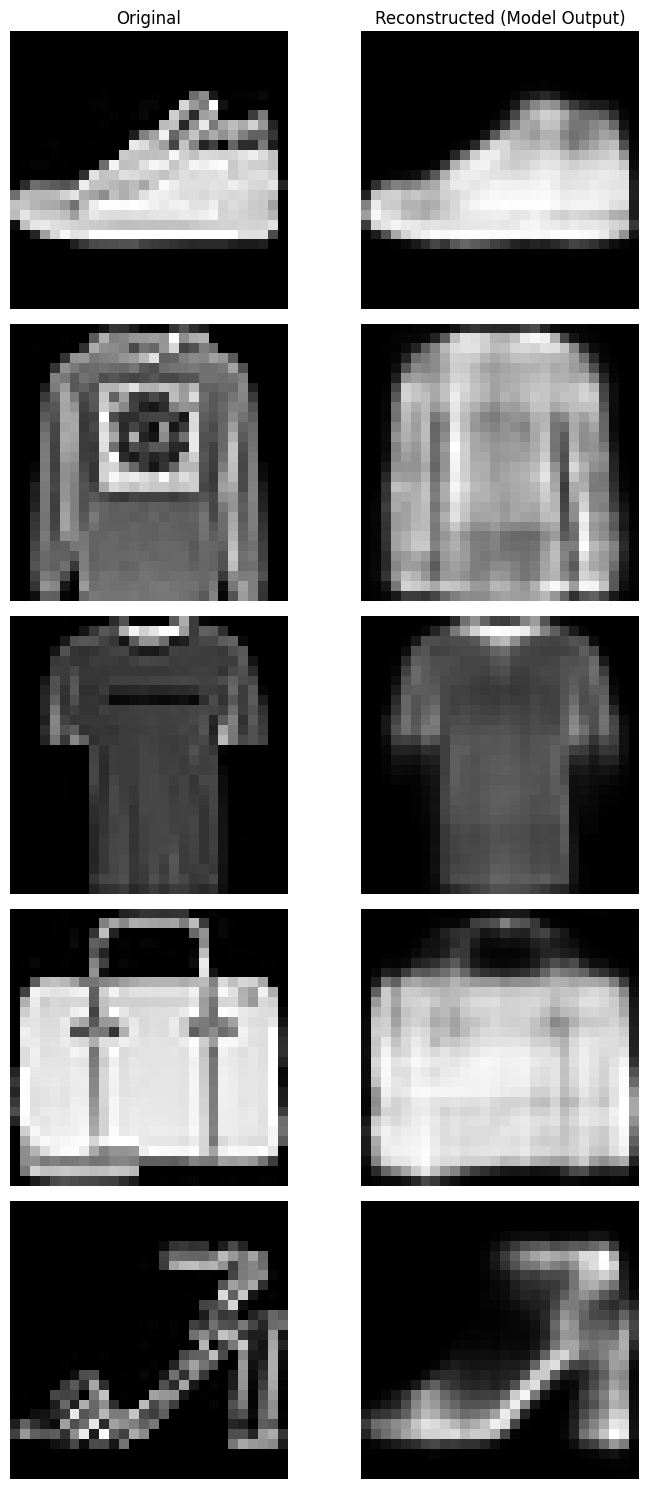

In [ ]:
def show_model_reconstructions_adam_warm_up(model, batch_images, count=5):
    """
    Visualizes original images vs. model reconstructions.
    """
    print("\nVisualizing Results...")

    model.eval()

    with torch.no_grad():
        inputs = batch_images[:count]
        reconstructions = model(inputs)

    plt.figure(figsize=(8, 3 * count))

    for i in range(count):
        img_orig = inputs[i].cpu().numpy().reshape(28, 28)
        img_recon = reconstructions[i].cpu().numpy().reshape(28, 28)

        # Original
        ax = plt.subplot(count, 2, i*2 + 1)
        plt.imshow(img_orig, cmap='gray')
        if i == 0: ax.set_title("Original")
        plt.axis('off')

        #Reconstructed
        ax = plt.subplot(count, 2, i*2 + 2)
        plt.imshow(img_recon, cmap='gray')
        if i == 0: ax.set_title("Reconstructed (Model Output)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# ---use example ---
data_iter = iter(train_loader)
sample_images = next(data_iter)[0]

show_model_reconstructions_adam_warm_up(trained_model, sample_images, count=5)

# The Experiment: Adam with Trapezoidal Schedule


## The Model Code


In [ ]:
import math
def run_model_optimization_experiment_with_adam_trapezoidal(
    optimizer_type: str,
    model: nn.Module,
    criterion: nn.Module,
    train_loader: DataLoader,
    epochs: int,
    learning_rate: float
):
    """
    Runs an optimization experiment to train the MODEL using Adam.
    Closer to the requested structure.
    """
    all_losses = []
    print(f"\nStarting MODEL {optimizer_type.upper()} optimization for {epochs} epochs (lr={learning_rate})...")
    total_start_time = time.time()

    max_lr = 0.0045
    min_lr = 0.00001
    warm_up_epochs = 7
    static_epochs = 6
    decay_epochs = epochs - warm_up_epochs - static_epochs
    current_lr = 0.0

    my_optimizer = None
    if optimizer_type == 'adam_trapezidal':
       my_optimizer = Adam_Optimizer(model.parameters(), learning_rate)

    for epoch in range(epochs):
        if epoch < warm_up_epochs:
          current_lr = max_lr * ((epoch + 1) / warm_up_epochs)

        elif epoch < warm_up_epochs + static_epochs:
          current_lr = max_lr

        else:
          decay_phase_start = warm_up_epochs + static_epochs
          steps_into_decay = epoch - decay_phase_start
          progress = steps_into_decay / decay_epochs
          cosine_factor = 0.5 * (1 + math.cos(math.pi * progress))
          current_lr = min_lr + (max_lr - min_lr) * cosine_factor

        my_optimizer.lr = current_lr
        epoch_loss = 0


        for batch_idx, batch in enumerate(train_loader):
            img = batch[0]

            calc_hessian_for_oracle = (optimizer_type == 'newton')
            loss, grads, hessians = autoencoder_oracle(model, criterion, img, calc_hessian=calc_hessian_for_oracle)

            epoch_loss += loss.item()

            # 2. Optimization step
            with torch.no_grad():
                if optimizer_type == 'adam_trapezidal':
                   my_optimizer.step(grads)

                else:
                    raise ValueError("Invalid optimizer type")

        avg_loss = epoch_loss / len(train_loader)
        all_losses.append(avg_loss)
        print(f"{avg_loss:.6f}")


        if (epoch + 1) % (epochs // 5) == 0 or epoch == 0 or epoch == epochs - 1:
            print(f"  Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.6f}")

    total_end_time = time.time()
    total_training_time = total_end_time - total_start_time
    print(f"\nTotal Training Time: {total_training_time:.2f} seconds")
    print(f"Finished {optimizer_type.upper()} optimization. Final Loss: {all_losses[-1]:.6f}")
    return model, all_losses

## The Experiment


Starting MODEL ADAM_TRAPEZIDAL optimization for 38 epochs (lr=0.0045)...
0.054965
  Epoch [1/38] Loss: 0.054965
0.023845
0.020093
0.018013
0.016446
0.015186
0.014219
  Epoch [7/38] Loss: 0.014219
0.013447
0.012861
0.012459
0.012056
0.011773
0.011524
0.011264
  Epoch [14/38] Loss: 0.011264
0.011081
0.010923
0.010792
0.010599
0.010460
0.010304
0.010146
  Epoch [21/38] Loss: 0.010146
0.010046
0.009890
0.009769
0.009641
0.009507
0.009434
0.009314
  Epoch [28/38] Loss: 0.009314
0.009228
0.009138
0.009052
0.008977
0.008918
0.008858
0.008806
  Epoch [35/38] Loss: 0.008806
0.008766
0.008738
0.008718
  Epoch [38/38] Loss: 0.008718

Total Training Time: 202.57 seconds
Finished ADAM_TRAPEZIDAL optimization. Final Loss: 0.008718


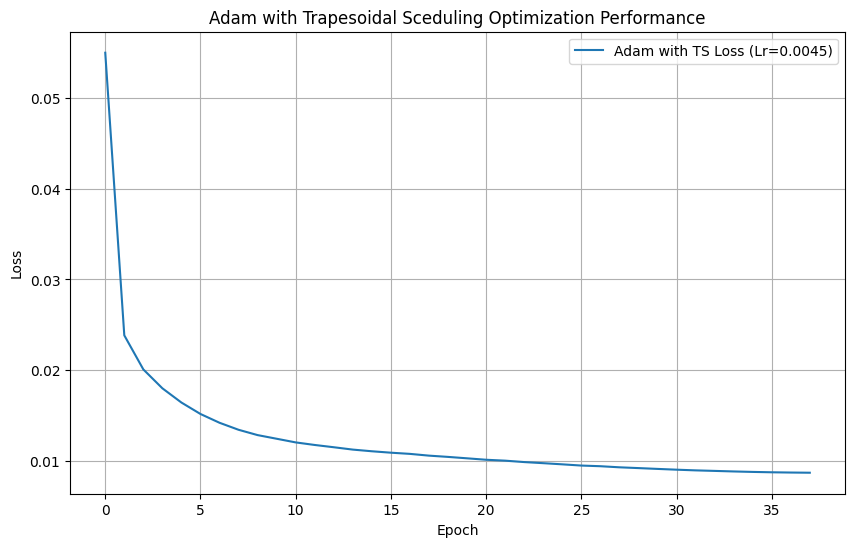

In [ ]:
# 1. Define your hyperparameters
optimizer_type = 'adam_trapezidal'
epochs = 38
learning_rate = 0.0045

# 2. Call the function
# We pass the 'autoencoder' model and 'train_loader' that were defined earlier in the notebook
trained_model, adam_trapezidal_losses = run_model_optimization_experiment_with_adam_trapezoidal(
    optimizer_type,
    Autoencoder(),
    nn.MSELoss(),
    train_loader,
    epochs,
    learning_rate
)

# 3. Plot the results (Optional but recommended)
plt.figure(figsize=(10, 6))
plt.plot(adam_trapezidal_losses, label=f'Adam with TS Loss (Lr={learning_rate})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Adam with Trapesoidal Sceduling Optimization Performance')
plt.legend()
plt.grid(True)
plt.show()

## The Reconstruction


Visualizing Results...


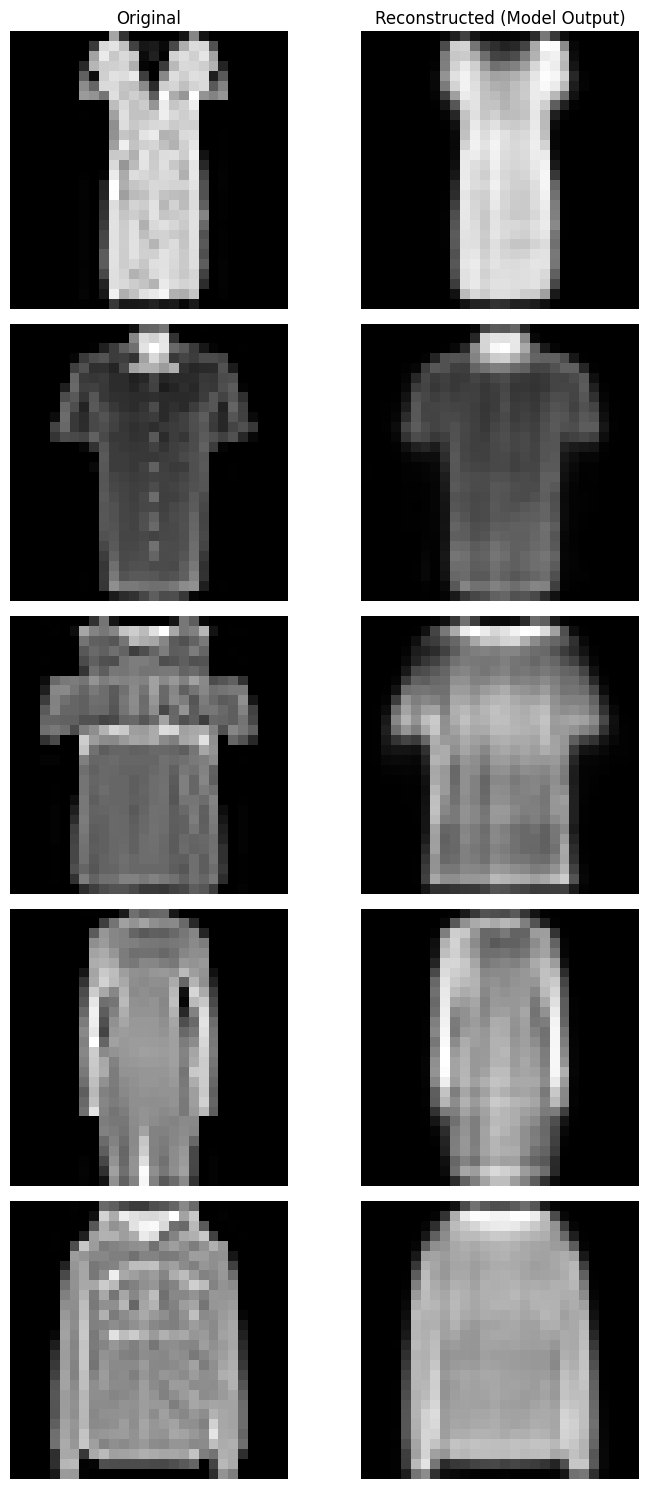

In [ ]:
def show_model_reconstructions_adam_trapezoidal(model, batch_images, count=5):
    """
    Visualizes original images vs. model reconstructions.
    """
    print("\nVisualizing Results...")

    model.eval()

    with torch.no_grad():
        inputs = batch_images[:count]
        reconstructions = model(inputs)

    plt.figure(figsize=(8, 3 * count))

    for i in range(count):
        img_orig = inputs[i].cpu().numpy().reshape(28, 28)
        img_recon = reconstructions[i].cpu().numpy().reshape(28, 28)

        # Original
        ax = plt.subplot(count, 2, i*2 + 1)
        plt.imshow(img_orig, cmap='gray')
        if i == 0: ax.set_title("Original")
        plt.axis('off')

        #Reconstructed
        ax = plt.subplot(count, 2, i*2 + 2)
        plt.imshow(img_recon, cmap='gray')
        if i == 0: ax.set_title("Reconstructed (Model Output)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# ---use example ---
data_iter = iter(train_loader)
sample_images = next(data_iter)[0]

show_model_reconstructions_adam_trapezoidal(trained_model, sample_images, count=5)

# The Code for Shampoo Optimizer

In [ ]:
class Shampoo_Optimizer:
    def __init__(self, model_parameters, adam_state=None, lr=0.01, epsilon=1e-4, update_freq=10):
        """
        Shampoo Optimizer with Adam Integration.

        Args:
            model_parameters: The list of model parameters to optimize.
            adam_state: (Optional) The state list from a previous Adam optimizer to inherit step counts.
            lr: Learning rate.
            epsilon: Small value added to diagonal for stability.
            update_freq: How often (in steps) to re-compute the inverse roots.
        """
        self.params = list(model_parameters)
        self.lr = lr
        self.epsilon = epsilon
        self.update_freq = update_freq

        # Initialize state (memory) for each parameter
        self.state = []

        for i, param in enumerate(self.params):
            state_dict = {
                'step': 0,             # Global step counter
                'preconditioners': [], # Stores correlation matrices
                'inverse_roots': []    # Stores calculated L^-1/4, R^-1/4
            }

            # INTEGRATION LOGIC:
            # If we were passed an Adam state, inherit the 'step' count (t)
            # We cannot inherit 'm' or 'v' because they are vectors, and we need matrices.
            if adam_state is not None and i < len(adam_state):
                state_dict['step'] = adam_state[i].get('t', 0)

            # Initialize Shampoo matrices for EACH dimension
            for dim_size in param.size():
                # Create square matrix (dim_size x dim_size)
                state_dict['preconditioners'].append(torch.zeros(dim_size, dim_size, device=param.device))
                state_dict['inverse_roots'].append(torch.eye(dim_size, device=param.device))

            self.state.append(state_dict)

    def _compute_root_inverse_eig(self, mat, order):
        """
        Computes mat^{-1/order} using exact Eigendecomposition.
        """
        L, V = torch.linalg.eigh(mat)
        L = torch.clamp(L, min=self.epsilon)
        inv_root_power = 1.0 / order
        inv_root_L = L.pow(-inv_root_power)
        return V @ torch.diag(inv_root_L) @ V.T

    def step(self, grads):
        """
        Performs one step of Shampoo optimization.
        """
        for param, grad, state in zip(self.params, grads, self.state):
            if grad is None:
                continue

            state['step'] += 1
            original_shape = grad.shape

            # ---------------------------------------------------------
            # Part A: Update Preconditioners
            # ---------------------------------------------------------
            for dim_id, dim_size in enumerate(original_shape):
                grad_reshaped = grad.transpose(dim_id, -1)
                grad_reshaped = grad_reshaped.reshape(-1, dim_size)
                state['preconditioners'][dim_id] += torch.matmul(grad_reshaped.T, grad_reshaped)

            # ---------------------------------------------------------
            # Part B: Compute Inverse Roots
            # ---------------------------------------------------------
            if state['step'] % self.update_freq == 0:
                order = 2 * len(original_shape)
                for dim_id, preconditioner in enumerate(state['preconditioners']):
                    mat = preconditioner + self.epsilon * torch.eye(preconditioner.shape[0], device=param.device)
                    inv_root = self._compute_root_inverse_eig(mat, order)
                    state['inverse_roots'][dim_id] = inv_root

            # ---------------------------------------------------------
            # Part C: Precondition the Gradient
            # ---------------------------------------------------------
            preconditioned_grad = grad.clone()
            for dim_id, inv_root in enumerate(state['inverse_roots']):
                preconditioned_grad = torch.tensordot(preconditioned_grad, inv_root, dims=[[dim_id], [0]])
                last_dim = len(original_shape) - 1
                preconditioned_grad = preconditioned_grad.moveaxis(last_dim, dim_id)

            # ---------------------------------------------------------
            # Part D: Update Weights
            # ---------------------------------------------------------
            param.data = param.data - self.lr * preconditioned_grad



# The Experiment: Shampoo Optimizer

## The Run Model Code

In [ ]:
def run_model_optimization_experiment_with_shampoo(
    optimizer_type: str,
    model: nn.Module,
    criterion: nn.Module,
    train_loader: DataLoader,
    epochs: int,
    learning_rate: float
):
    """
    Runs an optimization experiment to train the MODEL using GD or Newton.
    Closer to the requested structure.
    """
    all_losses = []
    print(f"\nStarting MODEL {optimizer_type.upper()} optimization for {epochs} epochs (lr={learning_rate})...")
    total_start_time = time.time()

    if optimizer_type == 'shampoo':
      # We use a default update_freq of 10 for the demo
      my_optimizer = Shampoo_Optimizer(model.parameters(), lr=learning_rate, update_freq=10)

    for epoch in range(epochs):
        epoch_loss = 0


        for batch_idx, batch in enumerate(train_loader):
            img = batch[0]

            calc_hessian_for_oracle = (optimizer_type == 'newton')
            loss, grads, hessians = autoencoder_oracle(model, criterion, img, calc_hessian=calc_hessian_for_oracle)

            epoch_loss += loss.item()

            # 2. Optimization step
            with torch.no_grad():
              if optimizer_type == 'shampoo':
                  my_optimizer.step(grads)

              else:
                  raise ValueError("Invalid optimizer type")

        avg_loss = epoch_loss / len(train_loader)
        all_losses.append(avg_loss)
        # to see if we can / delete
        print(avg_loss)


        if (epoch + 1) % (epochs // 5) == 0 or epoch == 0 or epoch == epochs - 1:
            print(f"  Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.6f}")

    total_end_time = time.time()
    total_training_time = total_end_time - total_start_time
    print(f"\nTotal Training Time: {total_training_time:.2f} seconds")
    print(f"Finished {optimizer_type.upper()} optimization. Final Loss: {all_losses[-1]:.6f}")
    return model, all_losses

## The Experiment

--- Starting SHAMPOO Experiment ---

Starting MODEL SHAMPOO optimization for 30 epochs (lr=0.48)...
0.047831479865096525
  Epoch [1/30] Loss: 0.047831
0.023091355894706143
0.01968381505435718
0.017780277834359263
0.016479464847523013
0.015534754324235768
  Epoch [6/30] Loss: 0.015535
0.014845534513738236
0.01431427838038534
0.013843907978631921
0.01346197253716653
0.013138721494484685
0.012845908750349017
  Epoch [12/30] Loss: 0.012846
0.01258939151554855
0.012378538942842214
0.01218210318997534
0.011985123336219839
0.011806754212675572
0.01164380962183989
  Epoch [18/30] Loss: 0.011644
0.011494527320697237
0.01136760590180977
0.011251519918680064
0.01113599411118577
0.011031598426592248
0.010928616473780893
  Epoch [24/30] Loss: 0.010929
0.010833008179087628
0.010748495973313033
0.010654224964506083
0.010580248634285255
0.010501934862784994
0.010423523632050959
  Epoch [30/30] Loss: 0.010424

Total Training Time: 720.89 seconds
Finished SHAMPOO optimization. Final Loss: 0.010424


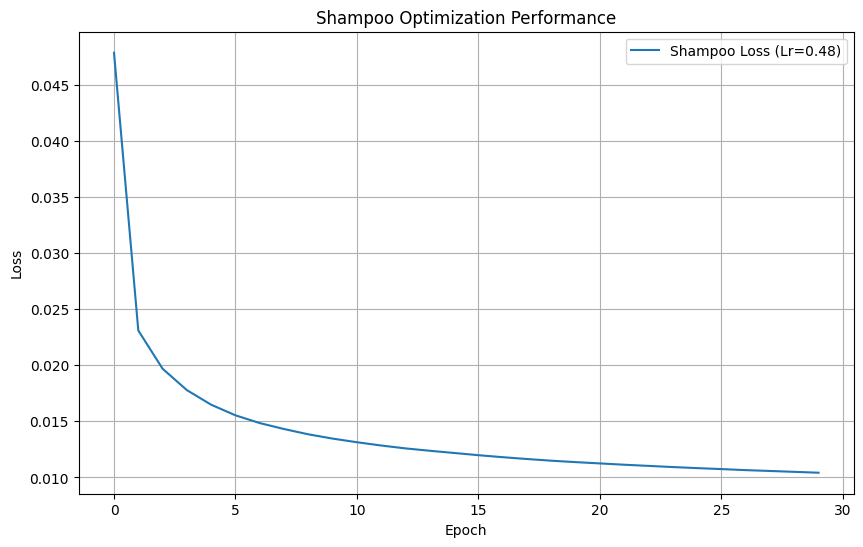

In [ ]:
autoencoder = Autoencoder()
criterion = nn.MSELoss()

# Hyperparameters
optimizer_type = 'shampoo'
epochs = 30
learning_rate = 0.48

# Run the experimentVisual
print(f"--- Starting {optimizer_type.upper()} Experiment ---")
trained_model, shampoo_losses = run_model_optimization_experiment_with_shampoo(
    optimizer_type,
    autoencoder,
    criterion,
    train_loader,
    epochs,
    learning_rate
)
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(shampoo_losses, label=f'Shampoo Loss (Lr={learning_rate})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Shampoo Optimization Performance')
plt.legend()
plt.grid(True)
plt.show()

## The Reconstruction


Visualizing Results...


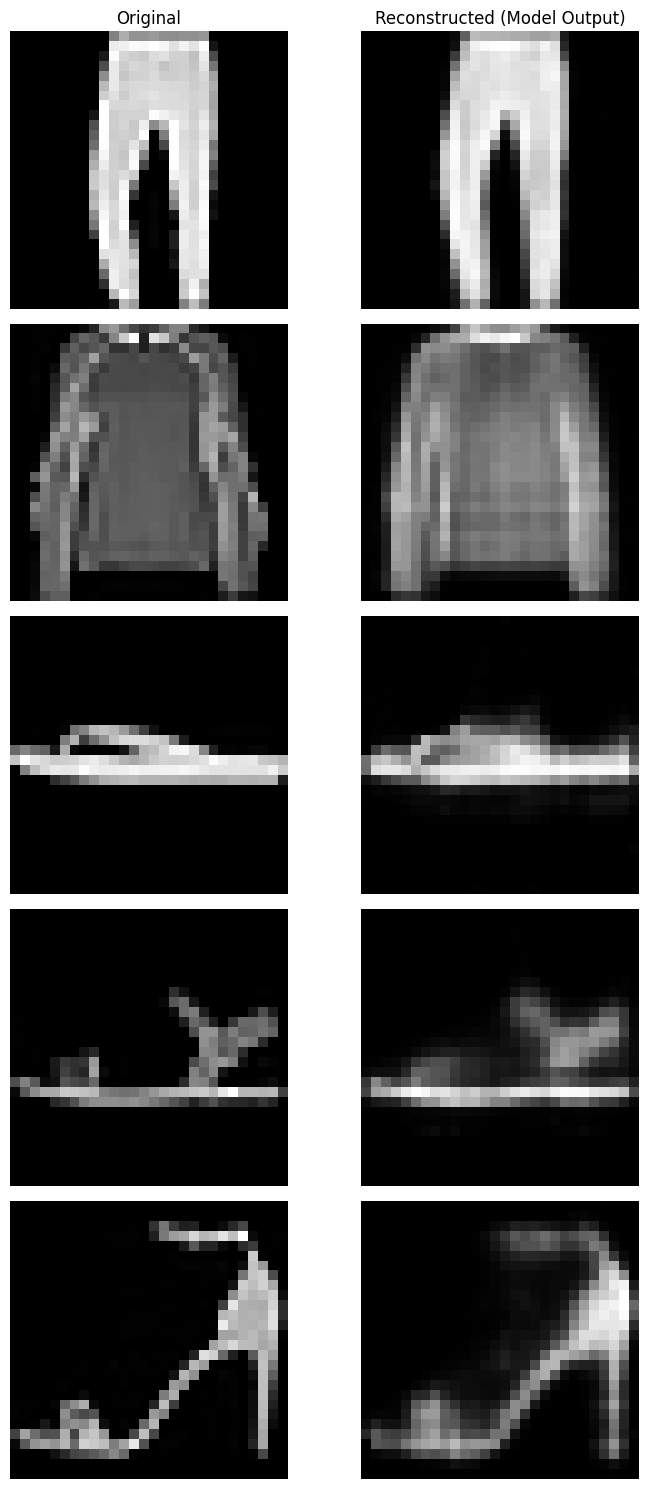

In [ ]:
def show_model_reconstructions_shampoo(model, batch_images, count=5):
    """
    Visualizes original images vs. model reconstructions.
    """
    print("\nVisualizing Results...")

    model.eval()

    with torch.no_grad():
        inputs = batch_images[:count]
        reconstructions = model(inputs)

    plt.figure(figsize=(8, 3 * count))

    for i in range(count):
        img_orig = inputs[i].cpu().numpy().reshape(28, 28)
        img_recon = reconstructions[i].cpu().numpy().reshape(28, 28)

        # Original
        ax = plt.subplot(count, 2, i*2 + 1)
        plt.imshow(img_orig, cmap='gray')
        if i == 0: ax.set_title("Original")
        plt.axis('off')

        #Reconstructed
        ax = plt.subplot(count, 2, i*2 + 2)
        plt.imshow(img_recon, cmap='gray')
        if i == 0: ax.set_title("Reconstructed (Model Output)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# ---use example ---
data_iter = iter(train_loader)
sample_images = next(data_iter)[0]

show_model_reconstructions_shampoo(trained_model, sample_images, count=5)

# The Experiment: Adam with Trapezoidal Scheduling integrated with shampoo


## The Run Modul

In [ ]:
import math
def run_model_optimization_experiment_with_adam_shampoo(
    optimizer_type: str,
    model: nn.Module,
    criterion: nn.Module,
    train_loader: DataLoader,
    epochs: int,
    learning_rate: float
):
    """
    Runs an optimization experiment to train the MODEL using Adam.
    Closer to the requested structure.
    """
    all_losses = []
    print(f"\nStarting MODEL {optimizer_type.upper()} optimization for {epochs} epochs (lr={learning_rate})...")
    total_start_time = time.time()

    max_lr = 0.0045
    min_lr = 0.00001
    warm_up_epochs = 7
    static_epochs = 6
    decay_epochs = epochs - warm_up_epochs - static_epochs
    shampoo_epochs = epochs - 5
    current_lr = 0.0

    my_optimizer = None
    if optimizer_type == 'adam_shampoo':
       my_optimizer = Adam_Optimizer(model.parameters(), learning_rate)

    for epoch in range(epochs):

        if epoch < warm_up_epochs:
          current_lr = max_lr * ((epoch + 1)/ warm_up_epochs)

        elif epoch < warm_up_epochs + static_epochs:
          current_lr = max_lr

        elif epoch < shampoo_epochs:
          decay_phase_start = warm_up_epochs + static_epochs
          steps_into_decay = epoch - decay_phase_start
          progress = steps_into_decay / decay_epochs
          cosine_factor = 0.5 * (1 + math.cos(math.pi * progress))
          current_lr = min_lr + (max_lr - min_lr) * cosine_factor

        my_optimizer.lr = current_lr
        epoch_loss = 0


        for batch_idx, batch in enumerate(train_loader):
            img = batch[0]

            calc_hessian_for_oracle = (optimizer_type == 'newton')
            loss, grads, hessians = autoencoder_oracle(model, criterion, img, calc_hessian=calc_hessian_for_oracle)

            epoch_loss += loss.item()

            # 2. Optimization step
            with torch.no_grad():
              if epoch < shampoo_epochs:
                if optimizer_type == 'adam_shampoo':
                   my_optimizer.step(grads)

                else:
                    raise ValueError("Invalid optimizer type")
              else:
                # Check if we need to switch (initialize Shampoo ONLY ONCE)
                if not isinstance(my_optimizer, Shampoo_Optimizer):
                    print("Switching from Adam to Shampoo...")

                    # Capture Adam's state before we overwrite the variable
                    previous_adam_state = my_optimizer.state

                    # Create Shampoo optimizer and pass the Adam state
                    my_optimizer = Shampoo_Optimizer(
                        model.parameters(),
                        adam_state=previous_adam_state,  # <--- PASS STATE HERE
                        lr=max_lr * 0.1  # Usually lower LR for Shampoo
                    )
                else:
                    my_optimizer.step(grads)

        avg_loss = epoch_loss / len(train_loader)
        all_losses.append(avg_loss)
        print(f"{avg_loss:.6f}")


        if (epoch + 1) % (epochs // 5) == 0 or epoch == 0 or epoch == epochs - 1:
            print(f"  Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.6f}")

    total_end_time = time.time()
    total_training_time = total_end_time - total_start_time
    print(f"\nTotal Training Time: {total_training_time:.2f} seconds")
    print(f"Finished {optimizer_type.upper()} optimization. Final Loss: {all_losses[-1]:.6f}")
    return model, all_losses

## The Experiment


Starting MODEL ADAM_SHAMPOO optimization for 38 epochs (lr=0.0045)...
0.056638
  Epoch [1/38] Loss: 0.056638
0.024943
0.020280
0.017803
0.016284
0.015203
0.014296
  Epoch [7/38] Loss: 0.014296
0.013532
0.012936
0.012481
0.012176
0.011849
0.011599
0.011446
  Epoch [14/38] Loss: 0.011446
0.011170
0.011010
0.010825
0.010633
0.010451
0.010340
0.010168
  Epoch [21/38] Loss: 0.010168
0.010045
0.009915
0.009826
0.009706
0.009587
0.009483
0.009382
  Epoch [28/38] Loss: 0.009382
0.009304
0.009196
0.009129
0.009047
0.008984
Switching from Adam to Shampoo...
0.008883
0.008864
  Epoch [35/38] Loss: 0.008864
0.008856
0.008852
0.008848
  Epoch [38/38] Loss: 0.008848

Total Training Time: 305.06 seconds
Finished ADAM_SHAMPOO optimization. Final Loss: 0.008848


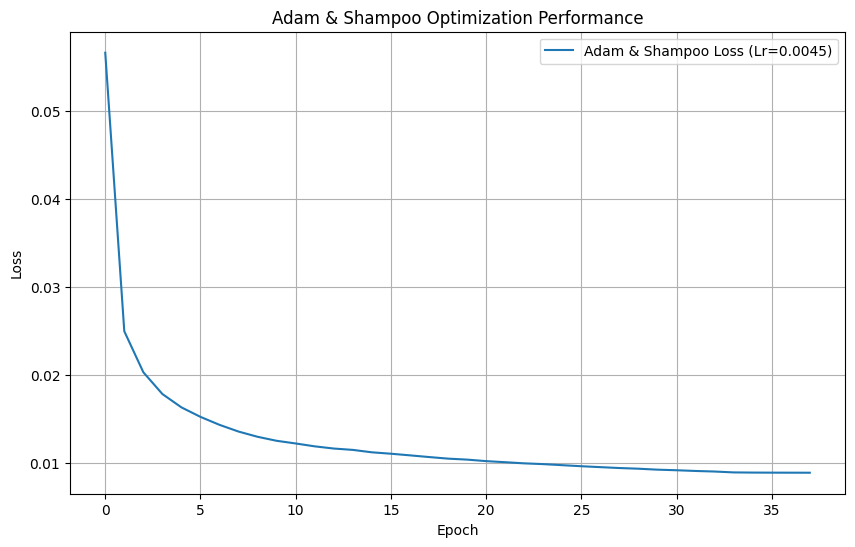

In [ ]:
# 1. Define your hyperparameters
optimizer_type = 'adam_shampoo'
epochs = 38
learning_rate = 0.0045

# 2. Call the function
# We pass the 'autoencoder' model and 'train_loader' that were defined earlier in the notebook
trained_model, adam_shampoo_losses = run_model_optimization_experiment_with_adam_shampoo(
    optimizer_type,
    Autoencoder(),
    nn.MSELoss(),
    train_loader,
    epochs,
    learning_rate
)

# 3. Plot the results (Optional but recommended)
plt.figure(figsize=(10, 6))
plt.plot(adam_shampoo_losses, label=f'Adam & Shampoo Loss (Lr={learning_rate})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Adam & Shampoo Optimization Performance')
plt.legend()
plt.grid(True)
plt.show()

## Compare Graph

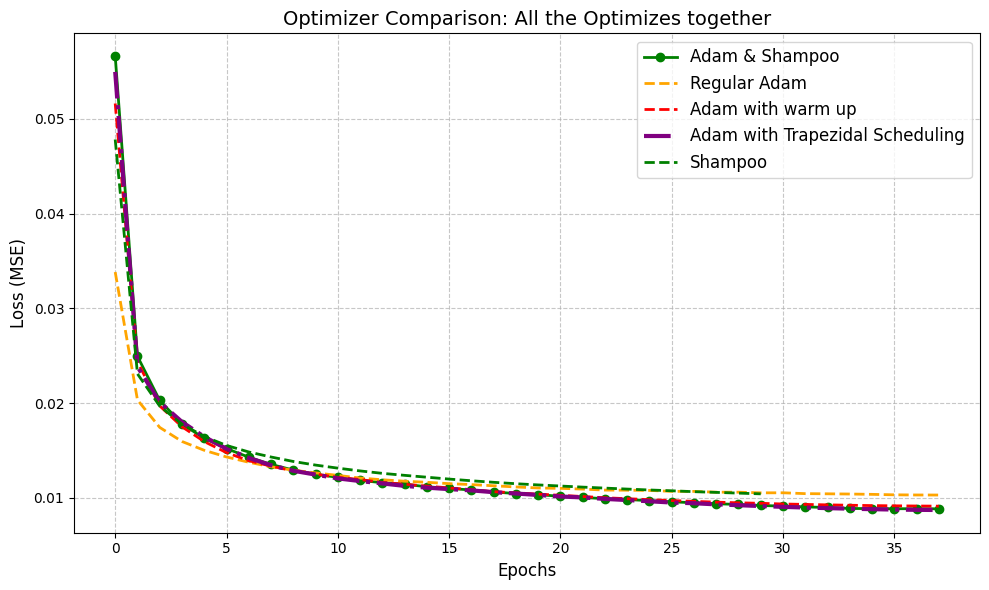

In [ ]:
plt.figure(figsize=(10, 6))

# Plot Shampoo Losses
plt.plot(adam_shampoo_losses, label='Adam & Shampoo', color='green', linewidth=2, marker='o')

# Plot Adam Losses (Assuming you ran the previous code block and have this variable)
# If you don't have adam_losses in memory, simply comment out the next line.
try:
    if 'adam_losses' in globals():
        plt.plot(adam_losses, label='Regular Adam', color='orange', linestyle='--', linewidth=2)
    if 'adam_warm_up_losses' in globals():
        plt.plot(adam_warm_up_losses, label='Adam with warm up', color='red', linestyle='--', linewidth=2)
    if 'adam_trapezidal_losses' in globals():
        plt.plot(adam_trapezidal_losses, label='Adam with Trapezidal Scheduling', color='purple', linestyle='-.', linewidth=3)
    if 'shampoo_losses' in globals():
        plt.plot(shampoo_losses, label='Shampoo', color='green',linestyle='--', linewidth=2)
except NameError:
    pass

# Graph Formatting
plt.title('Optimizer Comparison: All the Optimizes together', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

## The Reconstruction


Visualizing Results...


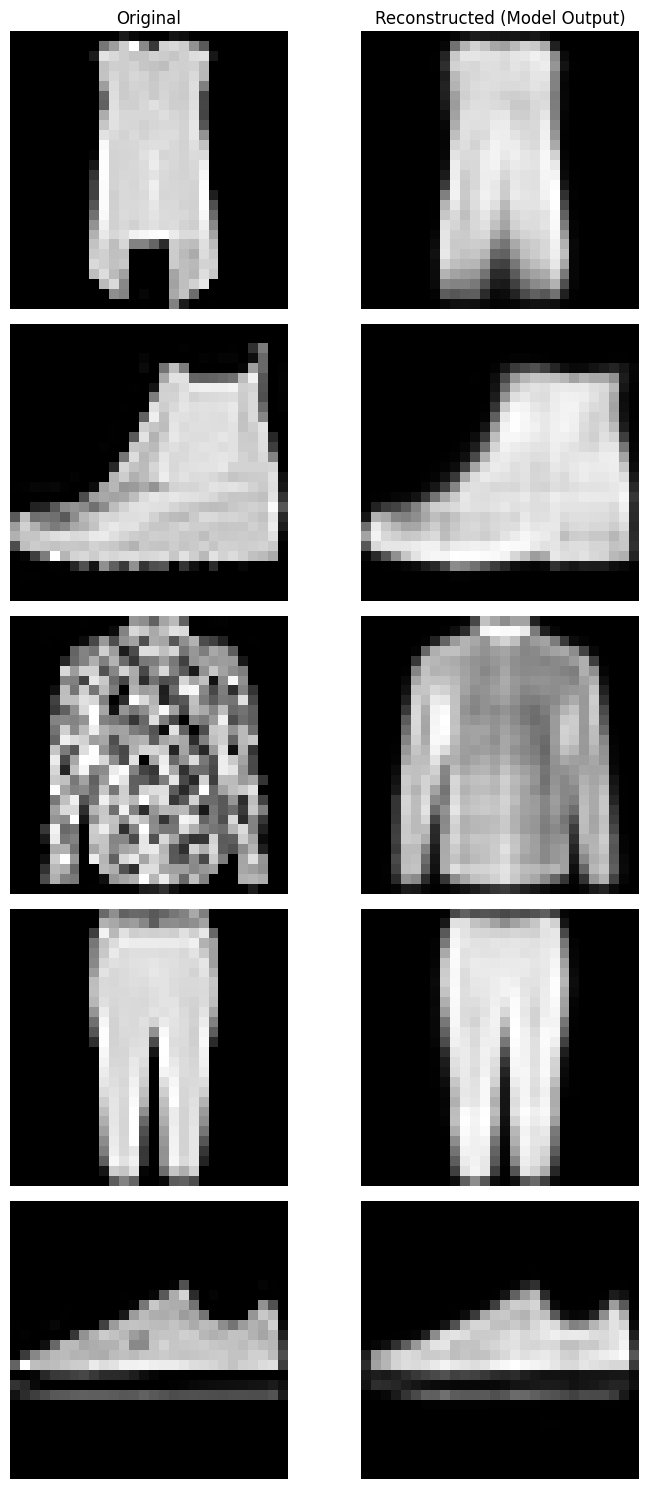

In [ ]:
def show_model_reconstructions_adam_shampoo(model, batch_images, count=5):
    """
    Visualizes original images vs. model reconstructions.
    """
    print("\nVisualizing Results...")

    model.eval()

    with torch.no_grad():
        inputs = batch_images[:count]
        reconstructions = model(inputs)

    plt.figure(figsize=(8, 3 * count))

    for i in range(count):
        img_orig = inputs[i].cpu().numpy().reshape(28, 28)
        img_recon = reconstructions[i].cpu().numpy().reshape(28, 28)

        # Original
        ax = plt.subplot(count, 2, i*2 + 1)
        plt.imshow(img_orig, cmap='gray')
        if i == 0: ax.set_title("Original")
        plt.axis('off')

        #Reconstructed
        ax = plt.subplot(count, 2, i*2 + 2)
        plt.imshow(img_recon, cmap='gray')
        if i == 0: ax.set_title("Reconstructed (Model Output)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# ---use example ---
data_iter = iter(train_loader)
sample_images = next(data_iter)[0]

show_model_reconstructions_adam_shampoo(trained_model, sample_images, count=5)

# To Sum up: we chose Adam with Trapezidal Scheduling because we got the minimal loss function with little time notation

## Main Insights: The experiment demonstrated that Adam with trapezoidal learning rate scheduling yielded better performance runtime wise compared to the hybrid Adam-Shampoo approach, contrary to the initial hypothesis. While Shampoo theoretically accounts for parameter correlations, the results suggest that the stability and continuous momentum of a well-scheduled first-order optimizer (Adam) were more effective for this specific task. The transition to Shampoo likely introduced volatility or required more extensive hyperparameter tuning than anticipated.
## Future Improvements: For future improvements, we would focus on investigating why the second-order optimization failed to generalize—perhaps by implementing a smoother "warm-start" mechanism to preserve momentum—or alternatively, simply further refining the trapezoidal schedule for Adam to maximize its proven efficiency without the added computational complexity.

# Visual Comparison of Optimized Images

In [ ]:
# def show_model_reconstructions(model, batch_images, count=5):
#     """
#     Visualizes original images vs. model reconstructions.
#     """
#     print("\nVisualizing Results...")

#     model.eval()

#     with torch.no_grad():
#         inputs = batch_images[:count]
#         reconstructions = model(inputs)

#     plt.figure(figsize=(8, 3 * count))

#     for i in range(count):
#         img_orig = inputs[i].cpu().numpy().reshape(28, 28)
#         img_recon = reconstructions[i].cpu().numpy().reshape(28, 28)

#         # Original
#         ax = plt.subplot(count, 2, i*2 + 1)
#         plt.imshow(img_orig, cmap='gray')
#         if i == 0: ax.set_title("Original")
#         plt.axis('off')

#         #Reconstructed
#         ax = plt.subplot(count, 2, i*2 + 2)
#         plt.imshow(img_recon, cmap='gray')
#         if i == 0: ax.set_title("Reconstructed (Model Output)")
#         plt.axis('off')

#     plt.tight_layout()
#     plt.show()

# # ---use example ---
# data_iter = iter(train_loader)
# sample_images = next(data_iter)[0]

# show_model_reconstructions(trained_model, sample_images, count=5)